
# metabeta — getting started

**metabeta** fits Bayesian mixed-effects models in milliseconds instead of minutes.
It uses a pre-trained neural network to approximate the posterior — no MCMC, no warmup.

This notebook walks through the full workflow on the classic `sleepstudy` dataset:
**load → sample → interpret.**


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

from metabeta.models.router import Router

mb = Router('/tmp/joint_normal_v1.pt', device='cpu')



## 1. Dataset

The `sleepstudy` dataset (Belenky et al. 2003) tracks reaction times (ms) for 18 subjects
across 10 days of sleep restriction — a two-level design with observations nested within
subjects. We refer to subjects as groups.


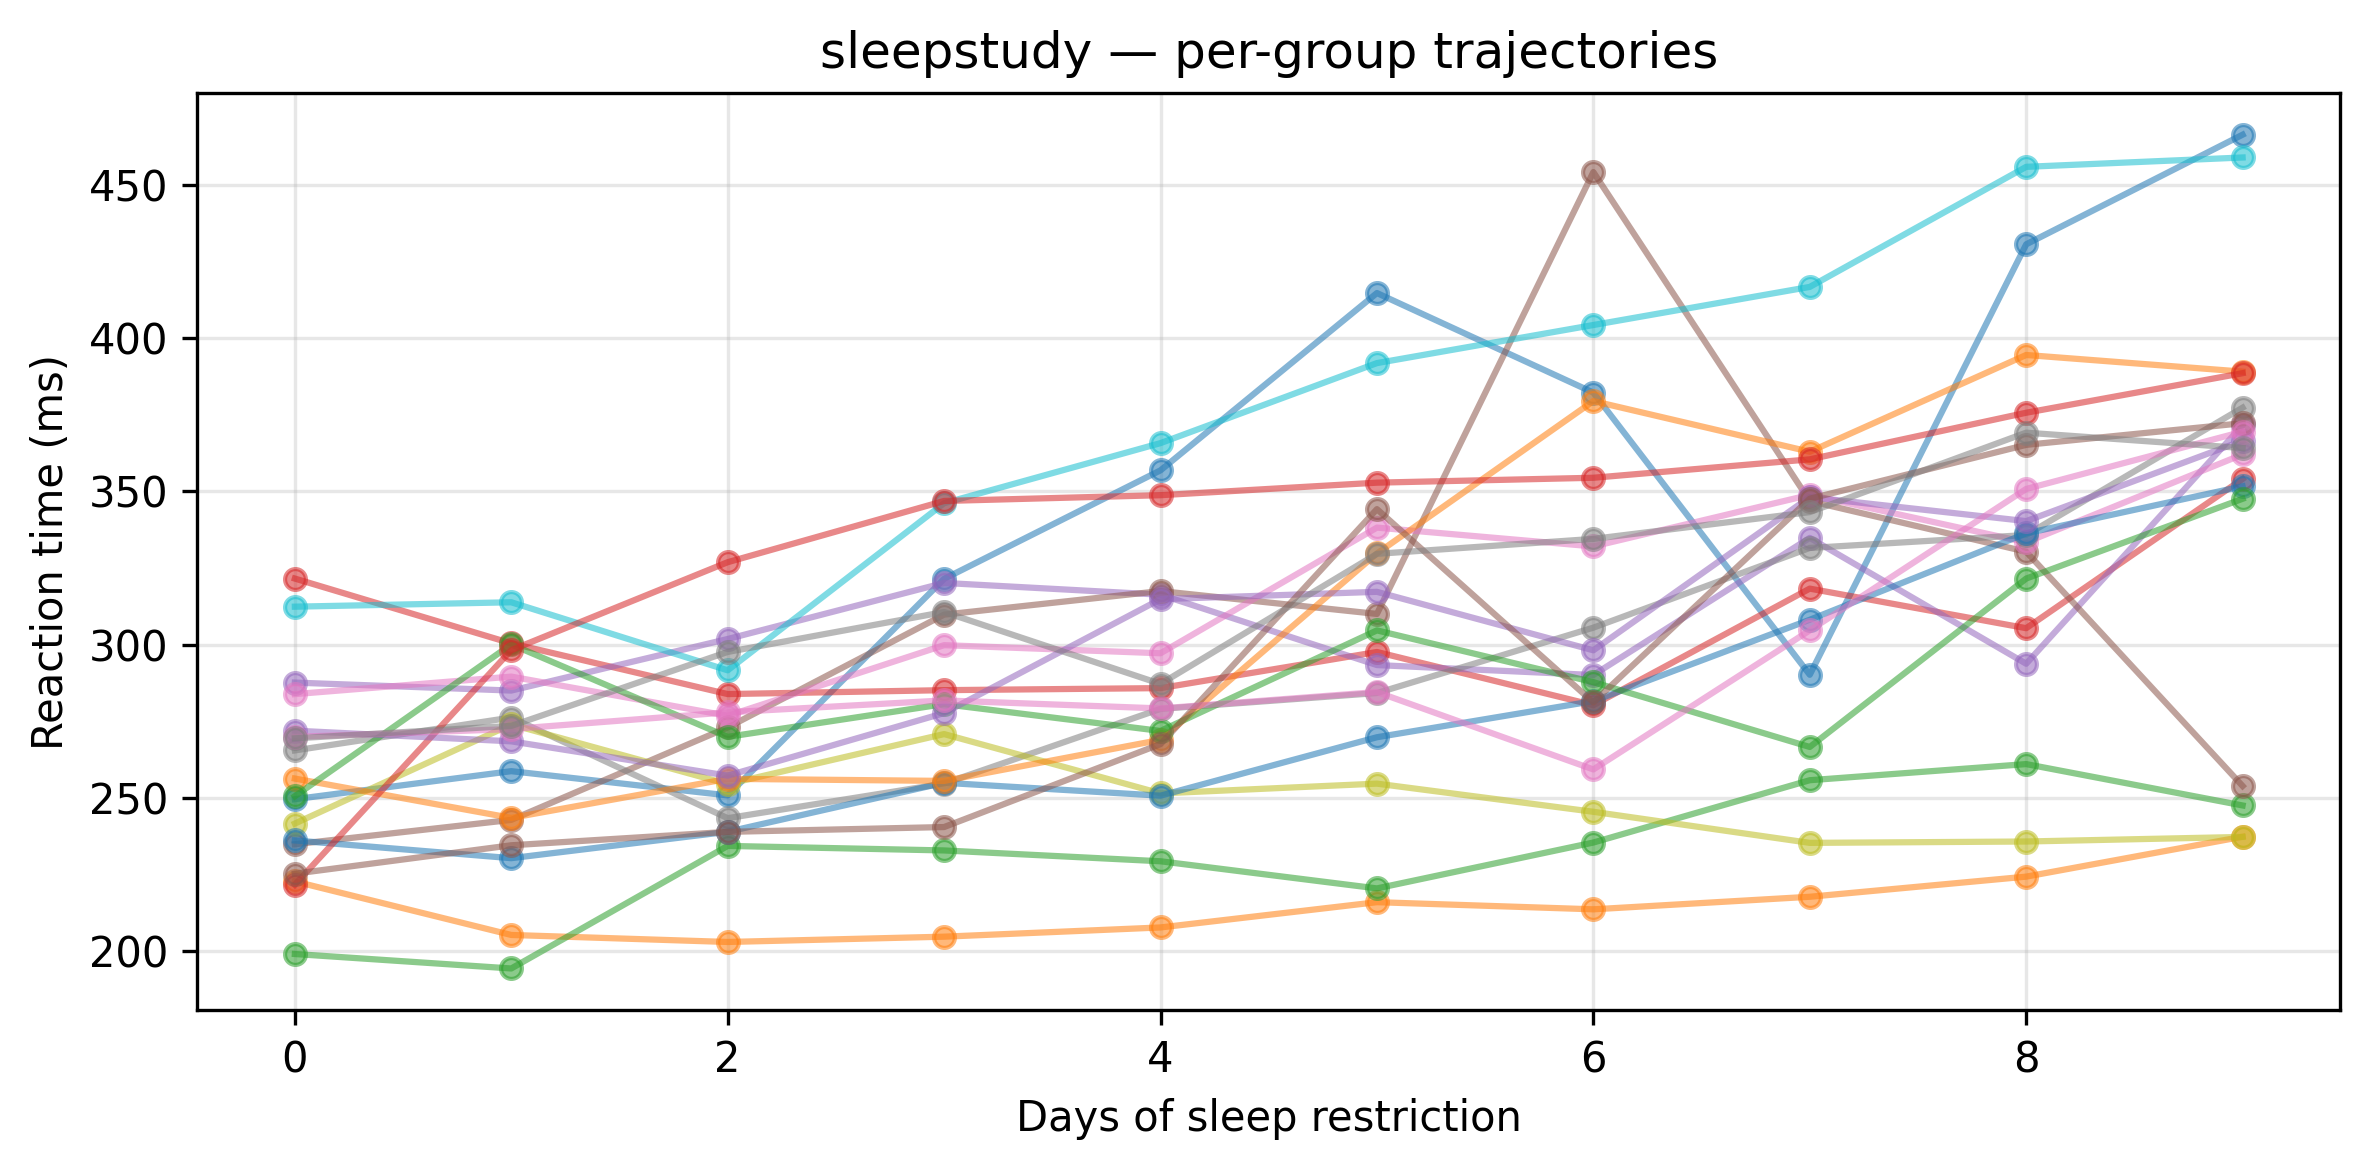

In [2]:
df = pd.read_parquet('../metabeta/datasets/from-r/parquet/sleep.parquet')

fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
for _, grp in df.groupby('group'):
    ax.plot(grp['Days'], grp['y'], 'o-', alpha=0.55, lw=1.5, ms=5)
ax.set_xlabel('Days of sleep restriction')
ax.set_ylabel('Reaction time (ms)')
ax.set_title('sleepstudy — per-group trajectories')
ax.grid(alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()



## 2. Inference

Describe the model with a standard **lme4-style formula**: `Days` as a fixed slope,
each subject gets its own random intercept.
`mb.sample()` handles preprocessing internally, routes to the right submodel, and
returns 1000 posterior draws in under a second.


In [3]:
result = mb.sample(
    df,
    formula='y ~ Days + (1 | group)',
    fit_preprocessor=True,
    n_samples=1000,
    diagnostics=True,
)



## 3. Results

All estimates are on the **original scale** of the data (ms).

| Column | Meaning |
|--------|---------|
| Mean · SD · 2.5% · 97.5% | Posterior mean, SD, and 95% credible interval |
| P(>0) | Posterior probability the effect is positive |
| Contr. | Posterior contraction — 1 = fully data-driven, 0 = prior-dominated |

Fit metrics at the bottom: **R²** (variance explained), **LOO-NLL** (leave-one-out
predictive performance [[1]](#notes)), and **Pareto k** (LOO reliability; < 0.7 is fine).


In [4]:
print(mb.posteriorSummary(result, x_scale='original'))


Formula:  y ~ Days + (1 | group)
n = 180   m = 18
Scale:    original  (slopes: Δy per unit predictor; σ and rfx: y units)
Priors:
  Intercept ~ N(298.5, 140.4)
  days ~ N(0, 48.89)
  σ_Intercept ~ HN(140.4)
  σ_Residual ~ HT₅(56.17)

Fixed Effects:
|           |    Mean |     SD |    2.5% |   97.5% |   P(>0) |   Contr. |
|:----------|--------:|-------:|--------:|--------:|--------:|---------:|
| Intercept | 250.823 | 12.400 | 227.742 | 276.752 |   1.000 |    0.992 |
| days      |  10.483 |  1.553 |   7.481 |  13.469 |   1.000 |    0.999 |

Standard Deviations (y units):
|           |   Mean |    SD |   2.5% |   97.5% |
|:----------|-------:|------:|-------:|--------:|
| Intercept | 39.876 | 8.076 | 27.615 |  58.857 |
| Residual  | 31.226 | 1.761 | 27.935 |  34.770 |

draws = 1000   R² = 0.726   LOO-NLL = 0.911   Pareto k = 0.240



### Per-subject random effects

Random intercept deviations from the population intercept, in ms.
**z** = posterior mean ÷ σ_Intercept; |z| > 2 flags an unusual group.
**SD ratio** = empirical SD of group estimates ÷ posterior mean of σ_Intercept [[2]](#notes).


In [5]:
print(mb.rfxSummary(result))


Random Effects:
Scale:    original y units  (intercept deviations from population intercept β₀)
|   Group |   n |   Intercept Mean |   Intercept 2.5% |   Intercept 97.5% |   Intercept z |
|---------|-----|------------------|------------------|-------------------|---------------|
|     308 |  10 |           41.523 |           13.579 |            68.630 |          1.04 |
|     309 |  10 |          -78.127 |         -106.225 |           -51.026 |         -1.96 |
|     310 |  10 |          -62.969 |          -90.429 |           -34.990 |         -1.58 |
|     330 |  10 |            5.137 |          -21.890 |            33.257 |          0.13 |
|     331 |  10 |           10.104 |          -15.761 |            36.881 |          0.25 |
|     332 |  10 |            8.616 |          -16.837 |            34.892 |          0.22 |
|     333 |  10 |           16.522 |           -9.979 |            43.659 |          0.41 |
|     334 |  10 |           -2.797 |          -29.180 |            24.123 | 

## 4. Posterior distributions

The pair grid shows the joint posterior over all global parameters.

- **Diagonal** — marginal posterior (green) with prior (blue) overlaid.
- **Upper triangle** — posterior scatter.
- **Lower triangle** — posterior density contours.

The prior shows a negative correlation between intercept and Days slope [[3]](#notes).


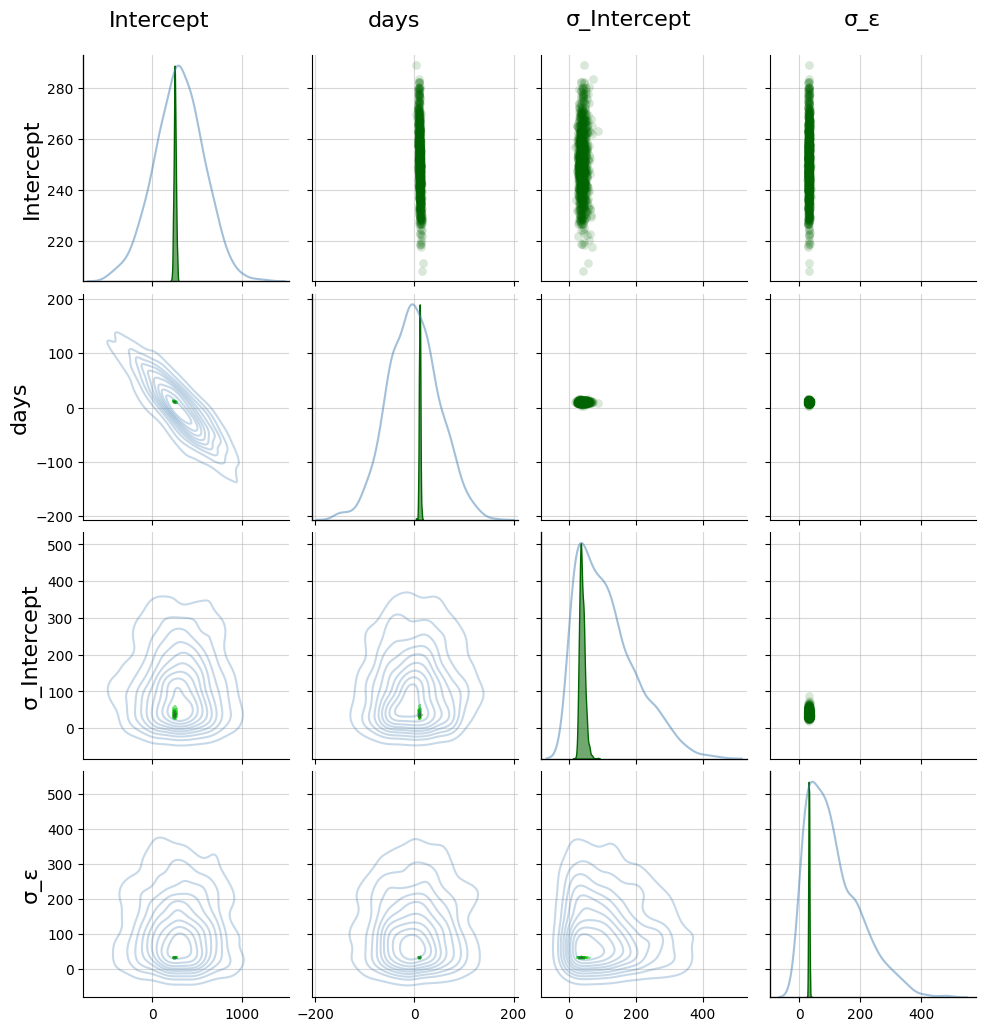

In [6]:
mb.plotParameters(result, with_prior=True);


<a id="notes"></a>

---

**Notes**

1. LOO-NLL uses PSIS leave-one-out cross-validation (Vehtari et al. 2017). Lower is better.
   Pareto k < 0.7 indicates reliable LOO estimates.

2. SD ratio compares the empirical SD of the RFX (over groups) with its posterior estimate. Values near 1 mean little shrinkage (many groups or large between-group variance relative to within-group noise). Values below 1 are expected: partial pooling shrinks group estimates toward zero, so their empirical SD underestimates
   the true σ. 

3. The neural model is trained with the intercept meaning "expected Y at mean(Days)", but the plot
   uses original-scale coordinates where the intercept is "expected Y at Days = 0".
   The conversion adds a correction −mean(Days)/SD(Days) × slope to the intercept, coupling
   both parameters through the same draw. For sleepstudy, mean(Days) ≈ 4.5 and
   SD(Days) ≈ 3.0, leading to correlated FFX priors in the original scale.
